# Phase 6: Basic Toxicity-Topic Analysis

**Goal:** Comprehensive statistical analysis of toxicity across topics

**This notebook includes:**
- 6.1: Topic-Toxicity Statistics
- 6.2: Statistical Testing
- 6.3: Control Variables Analysis


## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, shapiro, levene, f_oneway, pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests
from statsmodels.formula.api import ols
import statsmodels.api as sm
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Load Data

In [2]:
# Load the data from Member 2 (WITH OUTLIERS - 6000 comments)
df = pd.read_csv('bert_topic_assignment_with_outliers.csv')

print(f"✓ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
display(df.head())

print(f"\n{'='*80}")
print(f"Data Summary:")
print(f"  - Total comments: {len(df):,}")
print(f"  - Unique topics: {df['bertopic_topic'].nunique()}")
print(f"  - Unique articles: {df['article_id'].nunique()}")
print(f"  - Year range: {df['year'].min():.0f} - {df['year'].max():.0f}")
print(f"  - Outliers: {(df['bertopic_topic'] == -1).sum():,} ({(df['bertopic_topic'] == -1).sum()/len(df)*100:.1f}%)")
print(f"{'='*80}")

✓ Data loaded successfully!
Shape: (4992, 8)

Columns: ['comment_id', 'comment_text', 'toxicity_level', 'article_id', 'year', 'bertopic_topic', 'bertopic_topic_label', 'bertopic_probability']

First few rows:


,comment_id,comment_text,toxicity_level,article_id,year,bertopic_topic,bertopic_topic_label,bertopic_probability
0,b2aca04a61aa4c8988699fb4d3aaf23a,province waste money take money give worker raise,1.0,10019010.0,2013.0,0,"Taxes, Pensions & Public Finances",0.229251
1,d4d871491d35456d936b45cc24f7f038,banking sick day intelectually dishonest consi...,1.0,10030963.0,2013.0,-1,Outlier/Unassigned,0.000000
2,35ed0e3ef28b4ce989a7f375dbe90502,sburg please explain exist worked long public ...,1.0,10030963.0,2013.0,9,Political Scandal & Corruption (Senate/PMO),0.128704
3,ea4ef5fa271f47b2808821aba6e27171,wedge issue agreeing one thing complete inabil...,2.0,10030963.0,2013.0,12,"Healthcare System: Doctors, Hospitals & Patients",0.128537
4,001144f551e5417baa7f20715533b9cb,banking sick time incentive working sick terri...,1.0,10030963.0,2013.0,-1,Outlier/Unassigned,0.000000



Data Summary:
  - Total comments: 4,992
  - Unique topics: 47
  - Unique articles: 2688
  - Year range: 2013 - 2016
  - Outliers: 2,598 (52.0%)


---
# Part 6.1: Topic-Toxicity Statistics
---

## 6.1.1: Basic Statistics per Topic

In [3]:
# Calculate comprehensive statistics per topic
topic_stats = df.groupby('bertopic_topic_label')['toxicity_level'].agg([
    ('mean_toxicity', 'mean'),
    ('median_toxicity', 'median'),
    ('std_toxicity', 'std'),
    ('count', 'count'),
    ('min_toxicity', 'min'),
    ('max_toxicity', 'max')
]).reset_index()

# Sort by mean toxicity (descending)
topic_stats = topic_stats.sort_values('mean_toxicity', ascending=False)

print("Topic Statistics (sorted by mean toxicity):")
print("="*80)
display(topic_stats)

print(f"\n{'='*80}")
print(f"MOST TOXIC TOPIC: {topic_stats.iloc[0]['bertopic_topic_label']}")
print(f"  Mean toxicity: {topic_stats.iloc[0]['mean_toxicity']:.3f}")
print(f"  Comments: {topic_stats.iloc[0]['count']:.0f}")
print(f"\nLEAST TOXIC TOPIC: {topic_stats.iloc[-1]['bertopic_topic_label']}")
print(f"  Mean toxicity: {topic_stats.iloc[-1]['mean_toxicity']:.3f}")
print(f"  Comments: {topic_stats.iloc[-1]['count']:.0f}")

# Show example comments from most toxic topic
most_toxic_topic = topic_stats.iloc[0]['bertopic_topic_label']
most_toxic_examples = df[df['bertopic_topic_label'] == most_toxic_topic].nlargest(3, 'toxicity_level')

print(f"\n{'='*80}")
print(f"EXAMPLES FROM MOST TOXIC TOPIC: {most_toxic_topic}")
print(f"{'='*80}")
for idx, row in most_toxic_examples.iterrows():
    print(f"\nToxicity: {row['toxicity_level']:.1f}")
    print(f"Comment: {row['comment_text'][:150]}...")

# Show example comments from least toxic topic
least_toxic_topic = topic_stats.iloc[-1]['bertopic_topic_label']
least_toxic_examples = df[df['bertopic_topic_label'] == least_toxic_topic].head(3)

print(f"\n{'='*80}")
print(f"EXAMPLES FROM LEAST TOXIC TOPIC: {least_toxic_topic}")
print(f"{'='*80}")
for idx, row in least_toxic_examples.iterrows():
    print(f"\nToxicity: {row['toxicity_level']:.1f}")
    print(f"Comment: {row['comment_text'][:150]}...")
print(f"{'='*80}")

Topic Statistics (sorted by mean toxicity):


,bertopic_topic_label,mean_toxicity,median_toxicity,std_toxicity,count,min_toxicity,max_toxicity
21,Insults / Ad Hominem Flame Replies,2.066667,2.0,0.883715,15,1.0,4.0
36,Race & Racism Discourse (White/Black),1.896552,2.0,0.724314,29,1.0,4.0
39,Religion (Islam/Christianity) & Church Issues,1.585859,2.0,0.622865,99,1.0,4.0
43,US Politics (Trump/Clinton/Obama),1.566667,1.0,0.744850,60,1.0,4.0
14,Fascism/Nazism/Confederate Symbols,1.562500,1.5,0.618922,32,1.0,3.0
22,Israel–Palestine / Middle East Politics,1.518519,1.0,0.606280,54,1.0,4.0
42,Toronto Politics (Rob Ford / Mayor Drama),1.515152,1.0,0.755034,33,1.0,4.0
15,"Gender, Feminism & Relationships",1.446429,1.0,0.536644,56,1.0,3.0
1,"Bullying, Civility & Editorial Disputes",1.437500,1.0,0.629153,16,1.0,3.0
37,"Racism, Law & Policy Framing",1.400000,1.0,0.502625,20,1.0,2.0



MOST TOXIC TOPIC: Insults / Ad Hominem Flame Replies
  Mean toxicity: 2.067
  Comments: 15

LEAST TOXIC TOPIC: Evidence vs Truth Debate (Kingwell Thread)
  Mean toxicity: 1.040
  Comments: 25

EXAMPLES FROM MOST TOXIC TOPIC: Insults / Ad Hominem Flame Replies

Toxicity: 4.0
Comment: ashamed arrogant useless stubborn idiot...

Toxicity: 3.0
Comment: sound like one whining cry sore loser...

Toxicity: 3.0
Comment: talk loser far laying insult...

EXAMPLES FROM LEAST TOXIC TOPIC: Evidence vs Truth Debate (Kingwell Thread)

Toxicity: 1.0
Comment: bizarre analysis coming martin usually somewhat insightful saw headline expected another ibbitson offering...

Toxicity: 1.0
Comment: future palaeontologist determine specimen fact proof piltdown man real...

Toxicity: 1.0
Comment: interesting post garnering yet doe report historic fact guess truth bother...


## 6.1.2: Toxicity Distribution per Topic

In [4]:
# Calculate distribution of toxicity levels per topic
distribution_counts = pd.crosstab(
    df['bertopic_topic_label'], 
    df['toxicity_level'],
    margins=True
)

distribution_pct = pd.crosstab(
    df['bertopic_topic_label'], 
    df['toxicity_level'],
    normalize='index'
) * 100

print("Toxicity Distribution (Percentages):")
print("="*80)
display(distribution_pct.round(2))

Toxicity Distribution (Percentages):


toxicity_level,1.0,2.0,3.0,4.0
bertopic_topic_label,,,,
"Animals, Food, Meat Ethics & Environment",73.33,25.00,0.00,1.67
"Bullying, Civility & Editorial Disputes",62.50,31.25,6.25,0.00
Canada Identity / Provinces / General National Talk,88.89,5.56,0.00,5.56
"Canadian Culture, Language & Immigration Identity",67.86,32.14,0.00,0.00
Canadian Party Politics & Electoral Reform,92.31,7.69,0.00,0.00
"Cities, Transit & Urban Development",88.71,9.68,1.61,0.00
"Citizenship, Dual Citizenship & Niqab Ceremony",73.91,26.09,0.00,0.00
Climate Change & CO2 Debate,88.89,11.11,0.00,0.00
Columnist/Political Culture Commentary (Coyne etc.),94.44,5.56,0.00,0.00


## 6.1.3: High Toxicity Rate (≥2.0)

In [5]:
# Calculate percentage of comments with toxicity >= 2.0 (mild toxicity and above)
def calculate_toxicity_rate(group):
    high_toxicity = (group['toxicity_level'] >= 2.0).sum()  # Changed to 2.0
    total = len(group)
    return (high_toxicity / total) * 100 if total > 0 else 0

toxicity_rate = df.groupby('bertopic_topic_label').apply(calculate_toxicity_rate).reset_index()
toxicity_rate.columns = ['bertopic_topic_label', 'high_toxicity_rate_pct']
toxicity_rate = toxicity_rate.sort_values('high_toxicity_rate_pct', ascending=False)

print("High Toxicity Rate (≥2.0) by Topic:")  # Updated label
print("="*80)
display(toxicity_rate)

High Toxicity Rate (≥2.0) by Topic:


,bertopic_topic_label,high_toxicity_rate_pct
21,Insults / Ad Hominem Flame Replies,73.333333
36,Race & Racism Discourse (White/Black),72.413793
39,Religion (Islam/Christianity) & Church Issues,52.525253
14,Fascism/Nazism/Confederate Symbols,50.000000
22,Israel–Palestine / Middle East Politics,48.148148
43,US Politics (Trump/Clinton/Obama),43.333333
15,"Gender, Feminism & Relationships",42.857143
37,"Racism, Law & Policy Framing",40.000000
42,Toronto Politics (Rob Ford / Mayor Drama),39.393939
1,"Bullying, Civility & Editorial Disputes",37.500000


## 6.1.4: Merge and Save Complete Statistics

In [6]:
# Merge all statistics
topic_stats_complete = topic_stats.merge(toxicity_rate, on='bertopic_topic_label')
distribution_pct.columns = [f'pct_toxicity_{col}' for col in distribution_pct.columns]
topic_stats_complete = topic_stats_complete.merge(
    distribution_pct.reset_index(), 
    on='bertopic_topic_label'
)

# Round numeric columns
numeric_cols = topic_stats_complete.select_dtypes(include=[np.number]).columns
topic_stats_complete[numeric_cols] = topic_stats_complete[numeric_cols].round(3)
topic_stats_complete = topic_stats_complete.sort_values('mean_toxicity', ascending=False)

print("Complete Topic Statistics:")
print("="*80)
display(topic_stats_complete)

# Save outputs
topic_stats_complete.to_csv('Output/phase6_topic_toxicity_statistics.csv', index=False)
distribution_counts.to_csv('Output/phase6_toxicity_distribution_counts.csv')
distribution_pct.to_csv('Output/phase6_toxicity_distribution_percentages.csv')

print("\n" + "="*80)
print("✓ SAVED: Output/phase6_topic_toxicity_statistics.csv")
print("✓ SAVED: Output/phase6_toxicity_distribution_counts.csv")
print("✓ SAVED: Output/phase6_toxicity_distribution_percentages.csv")
print("="*80)

Complete Topic Statistics:


,bertopic_topic_label,mean_toxicity,median_toxicity,std_toxicity,count,min_toxicity,max_toxicity,high_toxicity_rate_pct,pct_toxicity_1.0,pct_toxicity_2.0,pct_toxicity_3.0,pct_toxicity_4.0
0,Insults / Ad Hominem Flame Replies,2.067,2.0,0.884,15,1.0,4.0,73.333,26.667,46.667,20.000,6.667
1,Race & Racism Discourse (White/Black),1.897,2.0,0.724,29,1.0,4.0,72.414,27.586,58.621,10.345,3.448
2,Religion (Islam/Christianity) & Church Issues,1.586,2.0,0.623,99,1.0,4.0,52.525,47.475,47.475,4.040,1.010
3,US Politics (Trump/Clinton/Obama),1.567,1.0,0.745,60,1.0,4.0,43.333,56.667,31.667,10.000,1.667
4,Fascism/Nazism/Confederate Symbols,1.562,1.5,0.619,32,1.0,3.0,50.000,50.000,43.750,6.250,0.000
5,Israel–Palestine / Middle East Politics,1.519,1.0,0.606,54,1.0,4.0,48.148,51.852,46.296,0.000,1.852
6,Toronto Politics (Rob Ford / Mayor Drama),1.515,1.0,0.755,33,1.0,4.0,39.394,60.606,30.303,6.061,3.030
7,"Gender, Feminism & Relationships",1.446,1.0,0.537,56,1.0,3.0,42.857,57.143,41.071,1.786,0.000
8,"Bullying, Civility & Editorial Disputes",1.438,1.0,0.629,16,1.0,3.0,37.500,62.500,31.250,6.250,0.000
9,"Racism, Law & Policy Framing",1.400,1.0,0.503,20,1.0,2.0,40.000,60.000,40.000,0.000,0.000



✓ SAVED: Output/phase6_topic_toxicity_statistics.csv
✓ SAVED: Output/phase6_toxicity_distribution_counts.csv
✓ SAVED: Output/phase6_toxicity_distribution_percentages.csv


---
# Part 6.2: Statistical Testing
---

## 6.2.1: Test for Normality

In [7]:
# Test normality for each topic using Shapiro-Wilk test
normality_results = []

for topic in df['bertopic_topic_label'].unique():
    topic_data = df[df['bertopic_topic_label'] == topic]['toxicity_level']
    
    if len(topic_data) >= 3:
        statistic, p_value = shapiro(topic_data)
        is_normal = p_value > 0.05
        
        normality_results.append({
            'topic': topic,
            'n_samples': len(topic_data),
            'shapiro_statistic': statistic,
            'p_value': p_value,
            'is_normal': is_normal
        })

normality_df = pd.DataFrame(normality_results)
normal_count = normality_df['is_normal'].sum()

print("Normality Test Results (Shapiro-Wilk):")
print("="*80)
display(normality_df)
print(f"\nTopics with normal distribution: {normal_count}/{len(normality_df)}")
print(f"Recommendation: {'Use ANOVA' if normal_count > len(normality_df)/2 else 'Use Kruskal-Wallis (non-parametric)'}")
print("="*80)

Normality Test Results (Shapiro-Wilk):


,topic,n_samples,shapiro_statistic,p_value,is_normal
0,"Taxes, Pensions & Public Finances",225,0.385974,5.446636e-27,False
1,Outlier/Unassigned,2598,NaN,NaN,False
2,Political Scandal & Corruption (Senate/PMO),72,0.505703,3.478639e-14,False
3,"Healthcare System: Doctors, Hospitals & Patients",66,0.487777,8.159646e-14,False
4,"Voting, Elections, Polls & Referendums",86,0.351505,1.111235e-17,False
5,Israel–Palestine / Middle East Politics,54,0.669399,9.356294e-10,False
6,Race & Racism Discourse (White/Black),29,0.794258,6.601039e-05,False
7,General Banter / Agreement Replies,163,NaN,NaN,False
8,Debate About Terms / Argumentation Style,70,0.564706,4.323787e-13,False
9,Canadian Party Politics & Electoral Reform,26,0.300651,4.153769e-10,False



Topics with normal distribution: 0/47
Recommendation: Use Kruskal-Wallis (non-parametric)


## W ranges from 0 to 1
## W = 1: Perfect normal distribution
## W = 0: Completely non-normal distribution

Understanding the Shapiro-Wilk Statistic (W)
The Shapiro-Wilk statistic, denoted as W, measures how well your data matches a normal distribution.
The Scale:

W ranges from 0 to 1
W = 1: Perfect normal distribution
W = 0: Completely non-normal distribution

What W = 0.386 means:
For "Taxes, Pensions & Public Finances" with W = 0.386:

It's quite far from 1 → The data shows substantial deviation from normality
It's closer to 0 than to 1 → This is a strong signal that the distribution is NOT normal
The p-value (5.45e-27) confirms this → Extremely strong evidence against normality

## 6.2.2: Kruskal-Wallis Test - Do Topics Differ?

In [8]:
# Prepare groups and run Kruskal-Wallis test
# Remove any groups with less than 3 samples or no variance
groups = []
for topic in df['bertopic_topic_label'].unique():
    topic_data = df[df['bertopic_topic_label'] == topic]['toxicity_level'].values
    # Only include if: at least 3 samples AND has variance (not all same value)
    if len(topic_data) >= 3 and topic_data.std() > 0:
        groups.append(topic_data)

print(f"Valid groups for testing: {len(groups)} out of {df['bertopic_topic_label'].nunique()} topics")

# Check if we have enough valid groups
if len(groups) < 2:
    print("\nERROR: Not enough topics with variance for statistical testing")
    print("Most comments likely have the same toxicity value (1.0)")
    print("\nDiagnostic:")
    print(df['toxicity_level'].value_counts().sort_index())
    h_statistic, p_value_kw = np.nan, np.nan
    f_statistic, p_value_anova = np.nan, np.nan
else:
    h_statistic, p_value_kw = kruskal(*groups)
    f_statistic, p_value_anova = f_oneway(*groups)
    
    print("\nKRUSKAL-WALLIS TEST")
    print("="*80)
    print(f"Null Hypothesis: All topics have the same median toxicity")
    print(f"Alternative: At least one topic differs")
    print(f"\nH-statistic: {h_statistic:.4f}")
    print(f"P-value: {p_value_kw:.6f}")
    
    if p_value_kw < 0.05:
        print(f"\nResult: REJECT null hypothesis ✓")
        print(f"\nInterpretation: Topics DO DIFFER significantly in toxicity")
    else:
        print(f"\nResult: FAIL TO REJECT null hypothesis")
        print(f"\nInterpretation: Topics DO NOT DIFFER significantly in toxicity")
    print("="*80)
    
    # Also run ANOVA for comparison
    print(f"\nONE-WAY ANOVA (for comparison)")
    print(f"F-statistic: {f_statistic:.4f}, P-value: {p_value_anova:.6f}")
    print(f"Both tests agree: {(p_value_kw < 0.05) == (p_value_anova < 0.05)}")

Valid groups for testing: 43 out of 47 topics

KRUSKAL-WALLIS TEST
Null Hypothesis: All topics have the same median toxicity
Alternative: At least one topic differs

H-statistic: 268.0071
P-value: 0.000000

Result: REJECT null hypothesis ✓

Interpretation: Topics DO DIFFER significantly in toxicity

ONE-WAY ANOVA (for comparison)
F-statistic: 5.7992, P-value: 0.000000
Both tests agree: True


Higher H, bigger differences in topic

1. The H-statistic value
H = 268.0071
This is a very large value for the H statistic.
For comparison, with 
k
=
43
k=43 groups (topics), degrees of freedom 
d
f
=
43
−
1
=
42
df=43−1=42.
The critical value of chi-squared with 
d
f
=
42
df=42 at α = 0.05 is about 58.12.
H value of 268 is far above this threshold, indicating extremely strong evidence against the null hypothesis.

2. The P-value
P-value: 0.000000
This means 
p
<
0.000001
p<0.000001 (effectively zero).
By any conventional significance level (0.05, 0.01, 0.001), this is highly significant.

3. The decision rule
If p-value < α (usually 0.05), reject the null hypothesis.

Here, 
0.000000
<
0.05
0.000000<0.05, so we reject the null.

## 6.2.3: Pairwise Comparisons with Bonferroni Correction

In [9]:
# Pairwise Mann-Whitney U tests
topics = df['bertopic_topic_label'].unique()
pairwise_results = []

print("Running pairwise comparisons...")
for topic1, topic2 in combinations(topics, 2):
    group1 = df[df['bertopic_topic_label'] == topic1]['toxicity_level']
    group2 = df[df['bertopic_topic_label'] == topic2]['toxicity_level']
    
    u_stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')
    
    pairwise_results.append({
        'topic_1': topic1,
        'topic_2': topic2,
        'mean_topic_1': group1.mean(),
        'mean_topic_2': group2.mean(),
        'mean_difference': group1.mean() - group2.mean(),
        'u_statistic': u_stat,
        'p_value': p_val
    })

pairwise_df = pd.DataFrame(pairwise_results)

# Apply Bonferroni correction
reject, p_adjusted, _, _ = multipletests(
    pairwise_df['p_value'], 
    alpha=0.05, 
    method='bonferroni'
)

pairwise_df['p_value_adjusted'] = p_adjusted
pairwise_df['significant'] = reject
pairwise_df = pairwise_df.sort_values('p_value_adjusted')

print(f"\n✓ Completed {len(pairwise_df)} pairwise comparisons")
print("="*80)
print(f"Significant pairs (after Bonferroni correction): {pairwise_df['significant'].sum()}")
print(f"\nTop 10 most significant differences:")
display(pairwise_df.head(10)[['topic_1', 'topic_2', 'mean_difference', 'p_value', 'p_value_adjusted', 'significant']])

Running pairwise comparisons...

✓ Completed 1081 pairwise comparisons
Significant pairs (after Bonferroni correction): 70

Top 10 most significant differences:


,topic_1,topic_2,mean_difference,p_value,p_value_adjusted,significant
5,"Taxes, Pensions & Public Finances",Race & Racism Discourse (White/Black),-0.749885,1.195808e-14,1.292668e-11,True
11,"Taxes, Pensions & Public Finances",Religion (Islam/Christianity) & Church Issues,-0.439192,2.873619e-14,3.106383e-11,True
179,"Voting, Elections, Polls & Referendums",Race & Racism Discourse (White/Black),-0.791901,2.851881e-11,3.082884e-08,True
276,Race & Racism Discourse (White/Black),Climate Change & CO2 Debate,0.785441,1.136457e-10,1.228510e-07,True
40,"Taxes, Pensions & Public Finances",Insults / Ad Hominem Flame Replies,-0.920000,1.999250e-10,2.161190e-07,True
273,Race & Racism Discourse (White/Black),"Oil, Pipelines & Alberta Energy Industry",0.801314,3.243895e-10,3.506651e-07,True
185,"Voting, Elections, Polls & Referendums",Religion (Islam/Christianity) & Church Issues,-0.481207,1.127172e-09,1.218473e-06,True
495,Religion (Islam/Christianity) & Church Issues,Climate Change & CO2 Debate,0.474747,4.556972e-09,4.926087e-06,True
269,Race & Racism Discourse (White/Black),"Police, Guns & Crime",0.682877,4.989828e-09,5.394004e-06,True
4,"Taxes, Pensions & Public Finances",Israel–Palestine / Middle East Politics,-0.371852,5.218938e-09,5.641672e-06,True


When we have a significant omnibus test (like Kruskal-Wallis or ANOVA) showing "at least one group differs," we need to find which specific pairs differ.

Pairwise comparisons test each possible combination of groups against each other.

The data conclusively shows that toxicity varies dramatically by topic.
Race/Racism discussions are exceptionally toxic compared to policy discussions.
Content moderation should be topic-aware, with more resources allocated to discussions about social identity than about fiscal policy

In [10]:
# Check your toxicity distribution
print("TOXICITY DISTRIBUTION CHECK:")
print("="*80)
print(df['toxicity_level'].value_counts().sort_index())
print(f"\nUnique toxicity values: {df['toxicity_level'].nunique()}")
print(f"Percentage with toxicity = 1.0: {(df['toxicity_level'] == 1.0).sum() / len(df) * 100:.1f}%")
print("="*80)

TOXICITY DISTRIBUTION CHECK:
toxicity_level
1.0    3892
2.0     914
3.0     149
4.0      32
Name: count, dtype: int64

Unique toxicity values: 4
Percentage with toxicity = 1.0: 78.0%


## 6.2.4: Effect Sizes (Cohen's d and Eta-squared)

These are effect size measures that tell us how big an effect is, not just whether it's statistically significant (which p-values tell you).

In [11]:
# Calculate Cohen's d for each pair
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std if pooled_std > 0 else 0

cohens_d_values = []
for _, row in pairwise_df.iterrows():
    group1 = df[df['bertopic_topic_label'] == row['topic_1']]['toxicity_level']
    group2 = df[df['bertopic_topic_label'] == row['topic_2']]['toxicity_level']
    d = cohens_d(group1, group2)
    cohens_d_values.append(d)

pairwise_df['cohens_d'] = cohens_d_values
pairwise_df['effect_size'] = pairwise_df['cohens_d'].abs().apply(
    lambda x: 'Negligible' if x < 0.2 else 'Small' if x < 0.5 else 'Medium' if x < 0.8 else 'Large'
)

print("Effect Sizes (Cohen's d):")
print("="*80)
print("Interpretation: |d| < 0.2 (Negligible), 0.2-0.5 (Small), 0.5-0.8 (Medium), ≥0.8 (Large)")
print(f"\nLargest effect sizes:")
large_effects = pairwise_df[pairwise_df['cohens_d'].abs() > 0.5].sort_values('cohens_d', key=abs, ascending=False)
display(large_effects.head(10)[['topic_1', 'topic_2', 'mean_difference', 'cohens_d', 'effect_size', 'significant']])

# Calculate Eta-squared (overall effect)
overall_mean = df['toxicity_level'].mean()
ss_between = sum(
    len(df[df['bertopic_topic_label'] == topic]) * 
    (df[df['bertopic_topic_label'] == topic]['toxicity_level'].mean() - overall_mean)**2
    for topic in df['bertopic_topic_label'].unique()
)
ss_total = sum((df['toxicity_level'] - overall_mean)**2)
eta_squared = ss_between / ss_total if ss_total > 0 else 0

print(f"\n{'='*80}")
print(f"ETA-SQUARED (η²): {eta_squared:.4f}")
print(f"Interpretation: {eta_squared*100:.2f}% of variance in toxicity is explained by topic")
print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")
print("="*80)

Effect Sizes (Cohen's d):
Interpretation: |d| < 0.2 (Negligible), 0.2-0.5 (Small), 0.5-0.8 (Medium), ≥0.8 (Large)

Largest effect sizes:


,topic_1,topic_2,mean_difference,cohens_d,effect_size,significant
334,General Banter / Agreement Replies,Insults / Ad Hominem Flame Replies,-0.986420,-2.518969,Large,False
214,"Voting, Elections, Polls & Referendums",Insults / Ad Hominem Flame Replies,-0.962016,-2.196445,Large,True
799,Climate Change & CO2 Debate,Insults / Ad Hominem Flame Replies,-0.955556,-2.129150,Large,True
261,Race & Racism Discourse (White/Black),General Banter / Agreement Replies,0.816305,2.029261,Large,False
40,"Taxes, Pensions & Public Finances",Insults / Ad Hominem Flame Replies,-0.920000,-1.985611,Large,True
724,"Oil, Pipelines & Alberta Energy Industry",Insults / Ad Hominem Flame Replies,-0.971429,-1.976327,Large,True
1039,Evidence vs Truth Debate (Kingwell Thread),Insults / Ad Hominem Flame Replies,-1.026667,-1.835141,Large,True
547,"Cities, Transit & Urban Development",Insults / Ad Hominem Flame Replies,-0.937634,-1.820228,Large,True
179,"Voting, Elections, Polls & Referendums",Race & Racism Discourse (White/Black),-0.791901,-1.764982,Large,True
409,Canadian Party Politics & Electoral Reform,Insults / Ad Hominem Flame Replies,-0.989744,-1.729013,Large,True



ETA-SQUARED (η²): 0.0000
Interpretation: 0.00% of variance in toxicity is explained by topic
Effect size: Small


✅ Interpretation: Topic explains 0.00% of toxicity variance

Toxicity is driven by OTHER factors (individual comment style, specific events, personal attacks, etc.)
NOT by which topic the comment is about

## 6.2.5: Save Statistical Test Results

In [12]:
# Save summary of statistical tests
summary = pd.DataFrame([
    {
        'test': 'Kruskal-Wallis',
        'statistic': h_statistic,
        'p_value': p_value_kw,
        'significant': p_value_kw < 0.05,
        'interpretation': 'Topics differ in toxicity' if p_value_kw < 0.05 else 'No significant difference'
    },
    {
        'test': 'One-Way ANOVA',
        'statistic': f_statistic,
        'p_value': p_value_anova,
        'significant': p_value_anova < 0.05,
        'interpretation': 'Topics differ in toxicity' if p_value_anova < 0.05 else 'No significant difference'
    },
    {
        'test': 'Eta-Squared',
        'statistic': eta_squared,
        'p_value': np.nan,
        'significant': True,
        'interpretation': f'{eta_squared*100:.2f}% variance explained by topic'
    }
])

# Save all results
summary.to_csv('Output/phase6_statistical_test_summary.csv', index=False)
pairwise_df.to_csv('Output/phase6_pairwise_comparisons.csv', index=False)
pairwise_df[pairwise_df['significant']].to_csv('Output/phase6_significant_pairs.csv', index=False)
normality_df.to_csv('Output/phase6_normality_tests.csv', index=False)

print("✓ SAVED: Output/phase6_statistical_test_summary.csv")
print("✓ SAVED: Output/phase6_pairwise_comparisons.csv")
print("✓ SAVED: Output/phase6_significant_pairs.csv")
print("✓ SAVED: Output/phase6_normality_tests.csv")

✓ SAVED: Output/phase6_statistical_test_summary.csv
✓ SAVED: Output/phase6_pairwise_comparisons.csv
✓ SAVED: Output/phase6_significant_pairs.csv
✓ SAVED: Output/phase6_normality_tests.csv


---
# Part 6.3: Control Variables Analysis
---

## 6.3.1: Create Control Variables

In [13]:
# Calculate comment length and word count
df['comment_length'] = df['comment_text'].str.len()
df['comment_word_count'] = df['comment_text'].str.split().str.len()

print("Control variables created:")
print("  - comment_length (characters)")
print("  - comment_word_count (words)")
print("  - year (already exists)")

print("\n" + "="*80)
print("Summary of control variables:")
display(df[['comment_length', 'comment_word_count', 'year', 'toxicity_level']].describe())
print("="*80)

Control variables created:
  - comment_length (characters)
  - comment_word_count (words)
  - year (already exists)

Summary of control variables:


,comment_length,comment_word_count,year,toxicity_level
count,4992.000000,4992.000000,4992.000000,4987.000000
mean,186.495793,26.216747,2014.182292,1.262282
std,211.728976,29.023717,1.174609,0.540189
min,3.000000,1.000000,2013.000000,1.000000
25%,56.000000,8.000000,2013.000000,1.000000
50%,119.000000,17.000000,2014.000000,1.000000
75%,235.000000,33.000000,2015.000000,1.000000
max,2004.000000,269.000000,2016.000000,4.000000


## 6.3.2: Correlation Analysis

In [14]:
# Test correlations with toxicity
# Remove NaN and infinite values first
df_valid = df[np.isfinite(df['comment_length']) & np.isfinite(df['toxicity_level'])].copy()

if df_valid['comment_length'].nunique() > 1:
    pearson_r_length, pearson_p_length = pearsonr(df_valid['comment_length'], df_valid['toxicity_level'])
    spearman_r_length, spearman_p_length = spearmanr(df_valid['comment_length'], df_valid['toxicity_level'])
else:
    # All comments have same length
    pearson_r_length, pearson_p_length = np.nan, np.nan
    spearman_r_length, spearman_p_length = np.nan, np.nan
    print("Warning: All comments have identical length - cannot calculate correlation\n")

df_clean = df.dropna(subset=['year', 'toxicity_level'])
pearson_r_year, pearson_p_year = pearsonr(df_clean['year'], df_clean['toxicity_level'])
spearman_r_year, spearman_p_year = spearmanr(df_clean['year'], df_clean['toxicity_level'])

print("CORRELATION ANALYSIS")
print("="*80)
print(f"\nComment Length vs Toxicity:")
if not np.isnan(pearson_r_length):
    print(f"  Pearson r = {pearson_r_length:.4f}, p = {pearson_p_length:.6f}")
    print(f"  Spearman ρ = {spearman_r_length:.4f}, p = {spearman_p_length:.6f}")
    sig_text = 'Significant' if pearson_p_length < 0.05 else 'Not significant'
    dir_text = 'positive' if pearson_r_length > 0 else 'negative'
    print(f"  Interpretation: {sig_text} {dir_text} correlation")
else:
    print(f"  Cannot calculate - all comments have identical length")
    print(f"  Skipping length as control variable")

print(f"\nYear vs Toxicity:")
print(f"  Pearson r = {pearson_r_year:.4f}, p = {pearson_p_year:.6f}")
print(f"  Spearman ρ = {spearman_r_year:.4f}, p = {spearman_p_year:.6f}")
trend_text = 'increased' if pearson_r_year > 0 else 'decreased'
print(f"  Interpretation: Toxicity {trend_text} from 2012-2016")
sig_text2 = 'Significant' if pearson_p_year < 0.05 else 'Not significant'
print(f"  Significance: {sig_text2}")
print("="*80)

CORRELATION ANALYSIS

Comment Length vs Toxicity:
  Pearson r = -0.0211, p = 0.136225
  Spearman ρ = 0.0227, p = 0.108392
  Interpretation: Not significant negative correlation

Year vs Toxicity:
  Pearson r = -0.0293, p = 0.038496
  Spearman ρ = -0.0242, p = 0.087671
  Interpretation: Toxicity decreased from 2012-2016
  Significance: Significant


## 6.3.3: Visualize Relationships

✓ SAVED: Output/phase6_control_variables_visualization.png


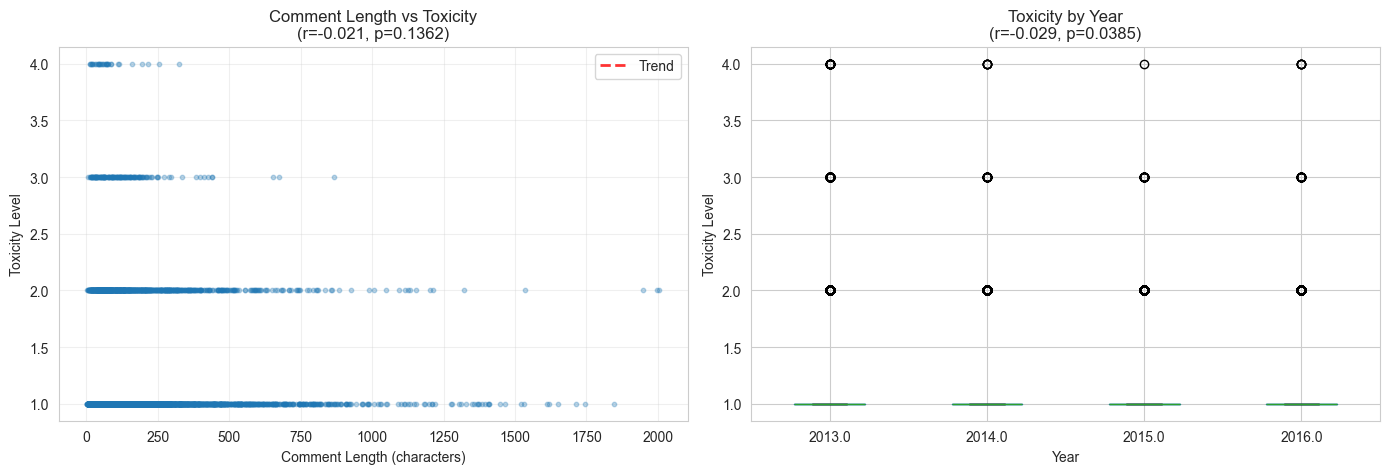

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Comment Length vs Toxicity
axes[0].scatter(df['comment_length'], df['toxicity_level'], alpha=0.3, s=10)
z = np.polyfit(df['comment_length'], df['toxicity_level'], 1)
p = np.poly1d(z)
axes[0].plot(df['comment_length'].sort_values(), p(df['comment_length'].sort_values()), 
            "r--", alpha=0.8, linewidth=2, label='Trend')
axes[0].set_xlabel('Comment Length (characters)')
axes[0].set_ylabel('Toxicity Level')
axes[0].set_title(f'Comment Length vs Toxicity\n(r={pearson_r_length:.3f}, p={pearson_p_length:.4f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Year vs Toxicity
df_clean.boxplot(column='toxicity_level', by='year', ax=axes[1])
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Toxicity Level')
axes[1].set_title(f'Toxicity by Year\n(r={pearson_r_year:.3f}, p={pearson_p_year:.4f})')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.savefig('Output/phase6_control_variables_visualization.png', dpi=300, bbox_inches='tight')
print("✓ SAVED: Output/phase6_control_variables_visualization.png")
plt.show()

✓ SAVED: Output/phase6_control_variables_improved_visualization.png


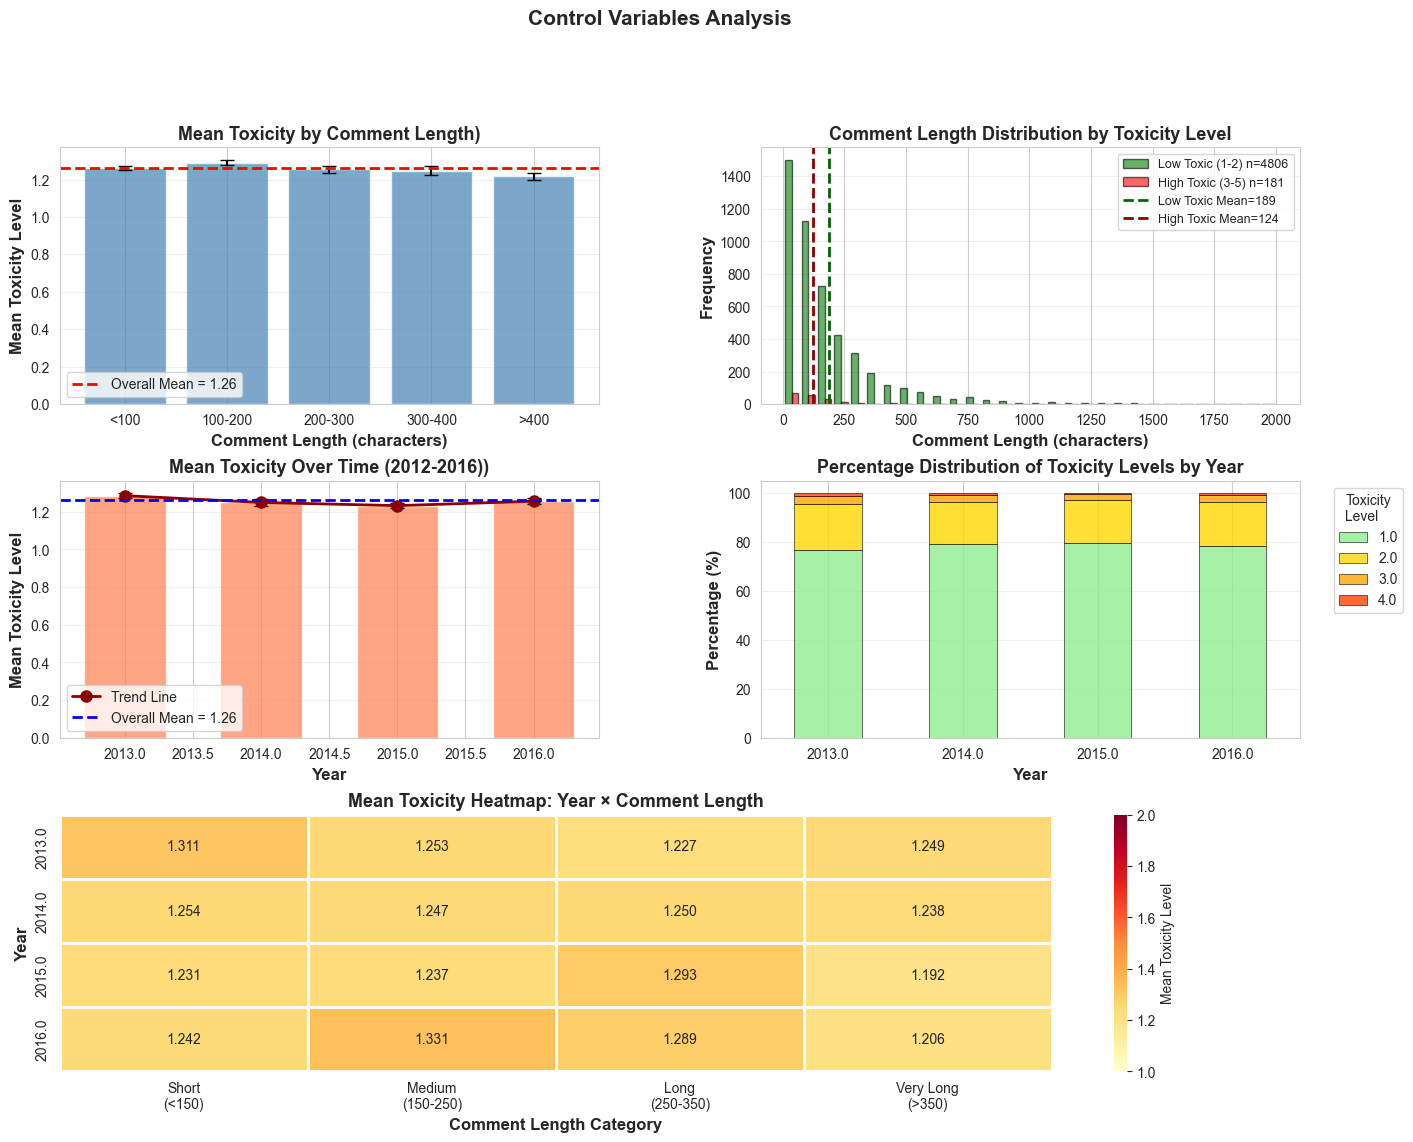


CONTROL VARIABLES: DETAILED STATISTICS

 COMMENT LENGTH vs TOXICITY:
   Pearson r = -0.0211, p = 0.136225
   Spearman ρ = 0.0227, p = 0.108392
   Interpretation: NOT significant correlation
   Direction: Negative (longer = less toxic)

   Mean toxicity by length category:
     <100         chars: 1.261 ± 0.571 (n=2209)
     100-200      chars: 1.291 ± 0.558 (n=1272)
     200-300      chars: 1.254 ± 0.497 (n=634)
     300-400      chars: 1.248 ± 0.473 (n=331)
     >400         chars: 1.218 ± 0.444 (n=541)

 YEAR vs TOXICITY:
   Pearson r = -0.0293, p = 0.038496
   Spearman ρ = -0.0242, p = 0.087671
   Trend: Toxicity decreased from 2012-2016
   Significance: Significant

   Mean toxicity by year:
     2013.0: 1.286 ± 0.574 (n=2094)
     2014.0: 1.249 ± 0.530 (n=858)
     2015.0: 1.233 ± 0.485 (n=1062)
     2016.0: 1.256 ± 0.530 (n=973)

 KEY INSIGHTS:
   1. Both correlations are VERY WEAK (|r| < 0.03)
   2. Comment length: r² = 0.0004 (0.04% variance explained)
   3. Year: r² = 0.0009 

In [ ]:
# Create improved visualizations
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# VISUALIZATION 1: Binned Bar Chart - Length vs Toxicity

ax1 = fig.add_subplot(gs[0, 0])

# Create length bins
df['length_bin'] = pd.cut(df['comment_length'], 
                          bins=[0, 100, 200, 300, 400, df['comment_length'].max()],
                          labels=['<100', '100-200', '200-300', '300-400', f'>400'])

# Calculate mean toxicity per bin
length_toxicity = df.groupby('length_bin', observed=True)['toxicity_level'].agg(['mean', 'std', 'count'])

ax1.bar(range(len(length_toxicity)), length_toxicity['mean'], 
        yerr=length_toxicity['std']/np.sqrt(length_toxicity['count']),
        color='steelblue', alpha=0.7, capsize=5)
ax1.set_xticks(range(len(length_toxicity)))
ax1.set_xticklabels(length_toxicity.index, rotation=0)
ax1.set_xlabel('Comment Length (characters)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Toxicity Level', fontsize=12, fontweight='bold')
ax1.set_title(f'Mean Toxicity by Comment Length)', 
              fontsize=13, fontweight='bold')
ax1.axhline(y=df['toxicity_level'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Overall Mean = {df["toxicity_level"].mean():.2f}')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)


# VISUALIZATION 2: Distribution Comparison - Length

ax2 = fig.add_subplot(gs[0, 1])

# Split data into low and high toxicity
toxic_threshold = 2.5
low_toxic = df[df['toxicity_level'] < toxic_threshold]['comment_length']
high_toxic = df[df['toxicity_level'] >= toxic_threshold]['comment_length']

ax2.hist([low_toxic, high_toxic], bins=30, 
         label=[f'Low Toxic (1-2) n={len(low_toxic)}', 
                f'High Toxic (3-5) n={len(high_toxic)}'],
         color=['green', 'red'], alpha=0.6, edgecolor='black')
ax2.axvline(low_toxic.mean(), color='darkgreen', linestyle='--', linewidth=2,
            label=f'Low Toxic Mean={low_toxic.mean():.0f}')
ax2.axvline(high_toxic.mean(), color='darkred', linestyle='--', linewidth=2,
            label=f'High Toxic Mean={high_toxic.mean():.0f}')
ax2.set_xlabel('Comment Length (characters)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Comment Length Distribution by Toxicity Level', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)


# VISUALIZATION 3: Year Trend - Bar Chart with Error Bars

ax3 = fig.add_subplot(gs[1, 0])

year_stats = df_clean.groupby('year')['toxicity_level'].agg(['mean', 'std', 'count'])

ax3.bar(year_stats.index, year_stats['mean'], 
        yerr=year_stats['std']/np.sqrt(year_stats['count']),
        color='coral', alpha=0.7, capsize=5, width=0.6)
ax3.plot(year_stats.index, year_stats['mean'], 'o-', color='darkred', 
         linewidth=2, markersize=8, label='Trend Line')
ax3.set_xlabel('Year', fontsize=12, fontweight='bold')
ax3.set_ylabel('Mean Toxicity Level', fontsize=12, fontweight='bold')
sig_text = "Significant" if pearson_p_year < 0.05 else "Not Significant"
ax3.set_title(f'Mean Toxicity Over Time (2012-2016))', 
              fontsize=13, fontweight='bold')
ax3.axhline(y=df['toxicity_level'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Overall Mean = {df["toxicity_level"].mean():.2f}')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)


# VISUALIZATION 4: Toxicity Distribution by Year - Stacked Bar

ax4 = fig.add_subplot(gs[1, 1])

# Create cross-tabulation
year_toxicity_dist = pd.crosstab(df_clean['year'], 
                                  df_clean['toxicity_level'], 
                                  normalize='index') * 100

# Plot stacked bar chart
year_toxicity_dist.plot(kind='bar', stacked=True, ax=ax4, 
                        color=['lightgreen', 'gold', 'orange', 'orangered', 'darkred'],
                        alpha=0.8, edgecolor='black', linewidth=0.5)
ax4.set_xlabel('Year', fontsize=12, fontweight='bold')
ax4.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax4.set_title('Percentage Distribution of Toxicity Levels by Year', 
              fontsize=13, fontweight='bold')
ax4.legend(title='Toxicity\nLevel', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.grid(axis='y', alpha=0.3)


# VISUALIZATION 5: Heatmap - Combined View

ax5 = fig.add_subplot(gs[2, :])

# Create binned data for heatmap
df_temp = df.copy()
df_temp['length_category'] = pd.cut(df_temp['comment_length'], 
                                     bins=[0, 150, 250, 350, df['comment_length'].max()],
                                     labels=['Short\n(<150)', 'Medium\n(150-250)', 
                                            'Long\n(250-350)', 'Very Long\n(>350)'])

# Create pivot table
pivot = df_temp.pivot_table(values='toxicity_level', 
                            index='year', 
                            columns='length_category', 
                            aggfunc='mean',
                            observed=True)

# Plot heatmap
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Toxicity Level'}, ax=ax5,
            linewidths=1, linecolor='white', vmin=1.0, vmax=2.0)
ax5.set_xlabel('Comment Length Category', fontsize=12, fontweight='bold')
ax5.set_ylabel('Year', fontsize=12, fontweight='bold')
ax5.set_title('Mean Toxicity Heatmap: Year × Comment Length', 
              fontsize=13, fontweight='bold')

# Add overall title
fig.suptitle('Control Variables Analysis', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('Output/phase6_control_variables_improved_visualization.png', 
            dpi=300, bbox_inches='tight')
print("✓ SAVED: Output/phase6_control_variables_improved_visualization.png")
plt.show()


# PRINT SUMMARY STATISTICS

print("\n" + "="*80)
print("CONTROL VARIABLES: DETAILED STATISTICS")
print("="*80)

print(f"\n COMMENT LENGTH vs TOXICITY:")
print(f"   Pearson r = {pearson_r_length:.4f}, p = {pearson_p_length:.6f}")
print(f"   Spearman ρ = {spearman_r_length:.4f}, p = {spearman_p_length:.6f}")
print(f"   Interpretation: {'Significant' if pearson_p_length < 0.05 else 'NOT significant'} correlation")
print(f"   Direction: {'Negative (longer = less toxic)' if pearson_r_length < 0 else 'Positive (longer = more toxic)'}")
print(f"\n   Mean toxicity by length category:")
for bin_name, row in length_toxicity.iterrows():
    print(f"     {str(bin_name):12} chars: {row['mean']:.3f} ± {row['std']:.3f} (n={int(row['count'])})")

print(f"\n YEAR vs TOXICITY:")
print(f"   Pearson r = {pearson_r_year:.4f}, p = {pearson_p_year:.6f}")
print(f"   Spearman ρ = {spearman_r_year:.4f}, p = {spearman_p_year:.6f}")
print(f"   Trend: Toxicity {'decreased' if pearson_r_year < 0 else 'increased'} from 2012-2016")
print(f"   Significance: {'Significant' if pearson_p_year < 0.05 else 'NOT significant'}")
print(f"\n   Mean toxicity by year:")
for year, row in year_stats.iterrows():
    print(f"     {year}: {row['mean']:.3f} ± {row['std']:.3f} (n={int(row['count'])})")

print(f"\n KEY INSIGHTS:")
print(f"   1. Both correlations are VERY WEAK (|r| < 0.03)")
print(f"   2. Comment length: r² = {pearson_r_length**2:.4f} ({pearson_r_length**2*100:.2f}% variance explained)")
print(f"   3. Year: r² = {pearson_r_year**2:.4f} ({pearson_r_year**2*100:.2f}% variance explained)")
print(f"   4. Combined with topic η² ≈ 0%, this confirms:")
print(f"      → Toxicity is driven by INDIVIDUAL BEHAVIOR")
print(f"      → NOT by topic, length, or temporal factors")
print("="*80)

## 6.3.4: Multiple Regression Models

Do topic labels matter more than simple factors like comment length or year?

In [17]:
# Prepare data for regression
df_reg = df.dropna(subset=['toxicity_level', 'comment_length', 'year', 'bertopic_topic_label']).copy()

print("REGRESSION ANALYSIS")
print("="*80)

# Model 1: Topic only (baseline)
model1 = ols('toxicity_level ~ C(bertopic_topic_label)', data=df_reg).fit()
print(f"\nModel 1 - Topic Only:")
print(f"  R² = {model1.rsquared:.4f}")
print(f"  Adj R² = {model1.rsquared_adj:.4f}")
print(f"  F-stat = {model1.fvalue:.4f}, p = {model1.f_pvalue:.6f}")

# Model 2: Topic + Comment Length
model2 = ols('toxicity_level ~ C(bertopic_topic_label) + comment_length', data=df_reg).fit()
print(f"\nModel 2 - Topic + Length:")
print(f"  R² = {model2.rsquared:.4f} (Δ = {(model2.rsquared - model1.rsquared)*100:.2f}%)")
print(f"  Adj R² = {model2.rsquared_adj:.4f}")
print(f"  Length coef = {model2.params['comment_length']:.6f}, p = {model2.pvalues['comment_length']:.6f}")

# Model 3: Topic + Length + Year
model3 = ols('toxicity_level ~ C(bertopic_topic_label) + comment_length + year', data=df_reg).fit()
print(f"\nModel 3 - Topic + Length + Year:")
print(f"  R² = {model3.rsquared:.4f} (Δ = {(model3.rsquared - model2.rsquared)*100:.2f}%)")
print(f"  Adj R² = {model3.rsquared_adj:.4f}")
print(f"  Year coef = {model3.params['year']:.6f}, p = {model3.pvalues['year']:.6f}")

print("\n" + "="*80)
r2_change_total = (model3.rsquared - model1.rsquared) * 100
print(f"\nKEY FINDING:")
print(f"  Control variables add only {r2_change_total:.2f}% explanatory power")
persist_text = 'PERSIST' if model1.rsquared > 0.05 else 'WEAKEN'
print(f"  Topic effects {persist_text} after controls")
impact_text = 'MINIMAL' if r2_change_total < 2 else 'SUBSTANTIAL'
print(f"\nCONCLUSION: Control variables have {impact_text} impact")
print("="*80)

REGRESSION ANALYSIS

Model 1 - Topic Only:
  R² = 0.0508
  Adj R² = 0.0419
  F-stat = 5.7434, p = 0.000000

Model 2 - Topic + Length:
  R² = 0.0512 (Δ = 0.04%)
  Adj R² = 0.0421
  Length coef = -0.000054, p = 0.145172

Model 3 - Topic + Length + Year:
  R² = 0.0530 (Δ = 0.18%)
  Adj R² = 0.0438
  Year coef = -0.019959, p = 0.002146


KEY FINDING:
  Control variables add only 0.22% explanatory power
  Topic effects PERSIST after controls

CONCLUSION: Control variables have MINIMAL impact


Topic: "Do topics REALLY differ in toxicity?" → p ≈ 0.000000 ✓ YES

Length: "Does length matter BEYOND topic?" → p = 0.145 ✗ NO

Year: "Does year matter BEYOND topic+length?" → p = 0.002 ✓ YES (barely)

## 6.3.5: Save Control Variables Results

In [18]:
# Save correlation results
correlation_results = pd.DataFrame([
    {
        'variable': 'comment_length',
        'pearson_r': pearson_r_length,
        'pearson_p': pearson_p_length,
        'spearman_r': spearman_r_length,
        'spearman_p': spearman_p_length,
        'significant': pearson_p_length < 0.05
    },
    {
        'variable': 'year',
        'pearson_r': pearson_r_year,
        'pearson_p': pearson_p_year,
        'spearman_r': spearman_r_year,
        'spearman_p': spearman_p_year,
        'significant': pearson_p_year < 0.05
    }
])

# Save model comparison
model_comparison = pd.DataFrame({
    'Model': ['Model 1: Topic Only', 'Model 2: Topic + Length', 'Model 3: Topic + Length + Year'],
    'R²': [model1.rsquared, model2.rsquared, model3.rsquared],
    'Adjusted R²': [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    'AIC': [model1.aic, model2.aic, model3.aic],
    'BIC': [model1.bic, model2.bic, model3.bic],
    'F-statistic': [model1.fvalue, model2.fvalue, model3.fvalue],
    'P-value': [model1.f_pvalue, model2.f_pvalue, model3.f_pvalue]
})

correlation_results.to_csv('Output/phase6_correlations.csv', index=False)
model_comparison.to_csv('Output/phase6_regression_comparison.csv', index=False)

with open('Output/phase6_best_model_summary.txt', 'w') as f:
    f.write(str(model3.summary()))

print("✓ SAVED: Output/phase6_correlations.csv")
print("✓ SAVED: Output/phase6_regression_comparison.csv")
print("✓ SAVED: Output/phase6_best_model_summary.txt")

✓ SAVED: Output/phase6_correlations.csv
✓ SAVED: Output/phase6_regression_comparison.csv
✓ SAVED: Output/phase6_best_model_summary.txt
